## Introdução
Este banco de dados é uma filtragem do TMDB (The Movie Database), incluindo apenas os filmes de horror, no qual a filtragem obedeceu aos critérios de:

* Gênero deve incluir **Horror**
* A **média de classificação** ser maior do que 7.0
* O filme tem uma **contagem de votos** acima de 100.


Colunas do banco de dados:
* title: Título do filme.
* id: Identificador de cada filme.
* overview: Uma breve sinopse do filme.
* genres: Gêneros associados ao filme.
* cast: Atores principais do filme.
* director: Diretor do filme.
* writers: Escritores do filme.
* production_companies: Companhias envolvidas na produção do filme.
* producers: Produtores que trabalharam no filme.
* original_language: Idioma em que o filme foi originalmente produzido.
* vote_average: Média de classificação do filme.
* vote_count: Número total de votos para o filme.
* runtime: Duração do filme em minutos.
* release_date: Data de lançamento do filme.

## Instalação e Tratamento dos Dados

In [23]:
import pandas as pd

In [24]:
# Importando o arquivo
df_backup = pd.read_csv('horror-movies.csv')
df_backup.head()

,title,id,overview,genres,cast,director,writers,production_companies,producers,original_language,vote_count,vote_average,popularity,runtime,release_date
0,The Conjuring 2,259693,Lorraine and Ed Warren travel to north London ...,Horror,"Vera Farmiga, Madison Wolfe, Simon Delaney, Ja...",James Wan,"David Leslie Johnson-McGoldrick, Carey Hayes, ...","New Line Cinema, The Safran Company, Atomic Mo...","Peter Safran, James Wan, Dave Neustadter, Rich...",en,8024,7.292,123.168,134,2016-06-08
1,A Nightmare on Elm Street,377,Teenagers in a small town are dropping like fl...,Horror,"John Saxon, Jack Shea, Donna Woodrum, Ronee Bl...",Wes Craven,Wes Craven,"New Line Cinema, Smart Egg Pictures, Media Hom...","Stanley Dudelson, Joseph Wolf, Sara Risher, Jo...",en,4823,7.332,54.918,91,1984-11-09
2,[REC],8329,A television reporter and cameraman follow eme...,"Horror, Mystery","Ben Temple, Carlos Vicente, Kao Chen-Min, Marí...","Jaume Balagueró, Paco Plaza","Jaume Balagueró, Paco Plaza, Luiso Berdejo","Filmax, Castelao Productions, Canal+ España, T...","Carlos Fernández, Julio Fernández",es,4147,7.193,31.367,78,2007-11-23
3,The Birds,571,Thousands of birds flock into a seaside town a...,Horror,"Mike Monteleone, Doreen Lang, Charles McGraw, ...",Alfred Hitchcock,"Daphne du Maurier, Evan Hunter",Alfred J. Hitchcock Productions,Alfred Hitchcock,en,3859,7.524,30.346,120,1963-03-28
4,The Evil Dead,764,Five vacationing college students unwittingly ...,Horror,"Bob Dorian, Cheryl Guttridge, Dorothy Tapert, ...",Sam Raimi,Sam Raimi,"Renaissance Pictures, New Line Cinema","Sam Raimi, Gary Holt, Bruce Campbell, Robert T...",en,3748,7.308,35.664,85,1981-09-10


In [25]:
# Verificando informações da base, bm como tamanho e tipos de dados
df_backup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 206 non-null    object 
 1   id                    206 non-null    int64  
 2   overview              206 non-null    object 
 3   genres                206 non-null    object 
 4   cast                  206 non-null    object 
 5   director              206 non-null    object 
 6   writers               206 non-null    object 
 7   production_companies  206 non-null    object 
 8   producers             206 non-null    object 
 9   original_language     206 non-null    object 
 10  vote_count            206 non-null    int64  
 11  vote_average          206 non-null    float64
 12  popularity            206 non-null    float64
 13  runtime               206 non-null    int64  
 14  release_date          206 non-null    object 
dtypes: float64(2), int64(3)

Limpeza dos dados para análise.

In [26]:
# Fazendo uma cópia da base para trabalhar com mais segurança
df = df_backup.copy()

In [27]:
df.shape

(206, 15)

In [28]:
# Conferindo as colunas existentes
df.columns

Index(['title', 'id', 'overview', 'genres', 'cast', 'director', 'writers',
       'production_companies', 'producers', 'original_language', 'vote_count',
       'vote_average', 'popularity', 'runtime', 'release_date'],
      dtype='object')

In [29]:
# Remoção de colunas que não serão utilizadas nesta análise
df.drop(["overview", "vote_count"], axis=1, inplace=True)

In [30]:
df.columns

Index(['title', 'id', 'genres', 'cast', 'director', 'writers',
       'production_companies', 'producers', 'original_language',
       'vote_average', 'popularity', 'runtime', 'release_date'],
      dtype='object')

In [31]:
# Conferindo dados nulos na base
nulos = df.isnull().sum()
print(nulos)

title                   0
id                      0
genres                  0
cast                    0
director                0
writers                 0
production_companies    0
producers               0
original_language       0
vote_average            0
popularity              0
runtime                 0
release_date            0
dtype: int64


In [32]:
# CXonferindo duplicatas na base
duplicados = df.duplicated().sum()
print(duplicados)

0


In [33]:
# Tansformando os dados da coluna 'release_date' pra o formato de data
df['release_date'] = pd.to_datetime(df['release_date'])

In [ ]:
# Unificando a data para apenas ano
df['release_date'] = df['release_date'].dt.year

In [35]:
# Conferindo se o tratamento foi bem sucedido
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 206 non-null    object 
 1   id                    206 non-null    int64  
 2   genres                206 non-null    object 
 3   cast                  206 non-null    object 
 4   director              206 non-null    object 
 5   writers               206 non-null    object 
 6   production_companies  206 non-null    object 
 7   producers             206 non-null    object 
 8   original_language     206 non-null    object 
 9   vote_average          206 non-null    float64
 10  popularity            206 non-null    float64
 11  runtime               206 non-null    int64  
 12  release_date          206 non-null    int32  
dtypes: float64(2), int32(1), int64(2), object(8)
memory usage: 20.2+ KB


In [36]:
df.describe()

,id,vote_average,popularity,runtime,release_date
count,2.060000e+02,206.000000,206.000000,206.000000,206.000000
mean,1.614418e+05,7.383942,32.373223,101.655340,1989.980583
std,2.571398e+05,0.284084,35.576335,28.211789,27.325493
min,1.360000e+02,7.001000,5.548000,5.000000,1920.000000
25%,4.312000e+03,7.141750,14.903500,91.000000,1974.250000
50%,2.233650e+04,7.332000,22.115000,103.000000,1996.000000
75%,2.455215e+05,7.522500,35.195250,114.750000,2013.750000
max,1.150394e+06,8.400000,381.745000,277.000000,2023.000000


In [37]:
# Renomeando as colunas para o Português
df.rename(columns={
    'title': 'Titulo',
    'genres': 'Genero',
    'cast': 'Elenco',
    'director': 'Direcao',
    'writers': 'Roteiristas',
    'production_companies': 'Produtoras',
    'producers': 'Produtores',
    'original_language': 'Idioma_Original',
    'vote_average': 'Media_Votos',
    'popularity': 'Popularidade',
    'runtime': 'Duracao',
    'release_date': 'Ano_Lancamento'
}, inplace=True)

In [38]:
df.columns

Index(['Titulo', 'id', 'Genero', 'Elenco', 'Direcao', 'Roteiristas',
       'Produtoras', 'Produtores', 'Idioma_Original', 'Media_Votos',
       'Popularidade', 'Duracao', 'Ano_Lancamento'],
      dtype='object')

In [39]:
# Separando a coluna de diretores para melhor análise
direcao_separada = df['Direcao'].str.split(', ', expand=True)
direcao_separada.columns = ['Diretor_1', 'Diretor_2', 'Diretor_3', 'Diretor_4']
df = pd.concat([df, direcao_separada], axis=1)

In [40]:
df.columns

Index(['Titulo', 'id', 'Genero', 'Elenco', 'Direcao', 'Roteiristas',
       'Produtoras', 'Produtores', 'Idioma_Original', 'Media_Votos',
       'Popularidade', 'Duracao', 'Ano_Lancamento', 'Diretor_1', 'Diretor_2',
       'Diretor_3', 'Diretor_4'],
      dtype='object')

In [41]:
# Separando a coluna de roteiristas para melhor análise
roteiro_separada = df['Roteiristas'].str.split(', ', expand=True)
roteiro_separada.columns = ['Roteirista_1', 'Roteirista_2', 'Roteirista_3', 'Roteirista_4', 'Roteirista_5', 'Roteirista_6', 'Roteirista_7', 'Roteirista_8', 'Roteirista_9', 'Roteirista_10', 'Roteirista_11']
df = pd.concat([df, roteiro_separada], axis=1)

In [42]:
df.columns

Index(['Titulo', 'id', 'Genero', 'Elenco', 'Direcao', 'Roteiristas',
       'Produtoras', 'Produtores', 'Idioma_Original', 'Media_Votos',
       'Popularidade', 'Duracao', 'Ano_Lancamento', 'Diretor_1', 'Diretor_2',
       'Diretor_3', 'Diretor_4', 'Roteirista_1', 'Roteirista_2',
       'Roteirista_3', 'Roteirista_4', 'Roteirista_5', 'Roteirista_6',
       'Roteirista_7', 'Roteirista_8', 'Roteirista_9', 'Roteirista_10',
       'Roteirista_11'],
      dtype='object')

In [48]:
df.head()

,Titulo,id,Genero,Elenco,Direcao,Roteiristas,Produtoras,Produtores,Idioma_Original,Media_Votos,...,Roteirista_2,Roteirista_3,Roteirista_4,Roteirista_5,Roteirista_6,Roteirista_7,Roteirista_8,Roteirista_9,Roteirista_10,Roteirista_11
0,The Conjuring 2,259693,Horror,"Vera Farmiga, Madison Wolfe, Simon Delaney, Ja...",James Wan,"David Leslie Johnson-McGoldrick, Carey Hayes, ...","New Line Cinema, The Safran Company, Atomic Mo...","Peter Safran, James Wan, Dave Neustadter, Rich...",en,7.292,...,Carey Hayes,James Wan,Chad Hayes,None,None,None,None,None,None,None
1,A Nightmare on Elm Street,377,Horror,"John Saxon, Jack Shea, Donna Woodrum, Ronee Bl...",Wes Craven,Wes Craven,"New Line Cinema, Smart Egg Pictures, Media Hom...","Stanley Dudelson, Joseph Wolf, Sara Risher, Jo...",en,7.332,...,None,None,None,None,None,None,None,None,None,None
2,[REC],8329,"Horror, Mystery","Ben Temple, Carlos Vicente, Kao Chen-Min, Marí...","Jaume Balagueró, Paco Plaza","Jaume Balagueró, Paco Plaza, Luiso Berdejo","Filmax, Castelao Productions, Canal+ España, T...","Carlos Fernández, Julio Fernández",es,7.193,...,Paco Plaza,Luiso Berdejo,None,None,None,None,None,None,None,None
3,The Birds,571,Horror,"Mike Monteleone, Doreen Lang, Charles McGraw, ...",Alfred Hitchcock,"Daphne du Maurier, Evan Hunter",Alfred J. Hitchcock Productions,Alfred Hitchcock,en,7.524,...,Evan Hunter,None,None,None,None,None,None,None,None,None
4,The Evil Dead,764,Horror,"Bob Dorian, Cheryl Guttridge, Dorothy Tapert, ...",Sam Raimi,Sam Raimi,"Renaissance Pictures, New Line Cinema","Sam Raimi, Gary Holt, Bruce Campbell, Robert T...",en,7.308,...,None,None,None,None,None,None,None,None,None,None


In [49]:
# Exportando a base tratada
df.to_csv('Horror_Movies_B.csv', sep=',', index=False)

## Analisando os Dados

In [70]:
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

Qual foi o ano com mais lançamentos de filmes de horror?

In [71]:
conn = sqlite3.connect(':memory:')

df.to_sql('df', conn, index=False, if_exists='replace')

query_sql = """
SELECT MAX(Ano_Lancamento) AS ano_maximo FROM df;
"""

ano_maximo_df = pd.read_sql_query(query_sql, conn)
ano_maximo = ano_maximo_df['ano_maximo'].iloc[0]
print(f"O ano com mais lançamentos de fimes de horror foi {ano_maximo}.")

conn.close()

O ano com mais lançamentos de fimes de horror foi 2023.


Evolução de lançamentos de filmes de horror.

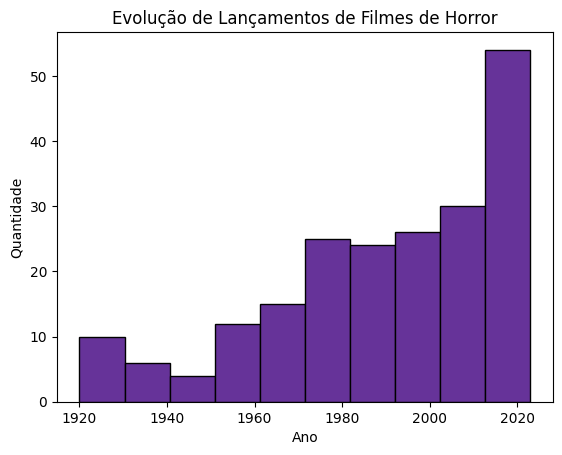

In [94]:
df["Ano_Lancamento"].plot.hist(edgecolor="black", color="rebeccapurple")
plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.title("Evolução de Lançamentos de Filmes de Horror")

plt.show()

> Aparentemente houve um crescimento ao longo dos anos na produção de filmes de horror bem avaliados.

Quais filmes possuem melhores avaliações?

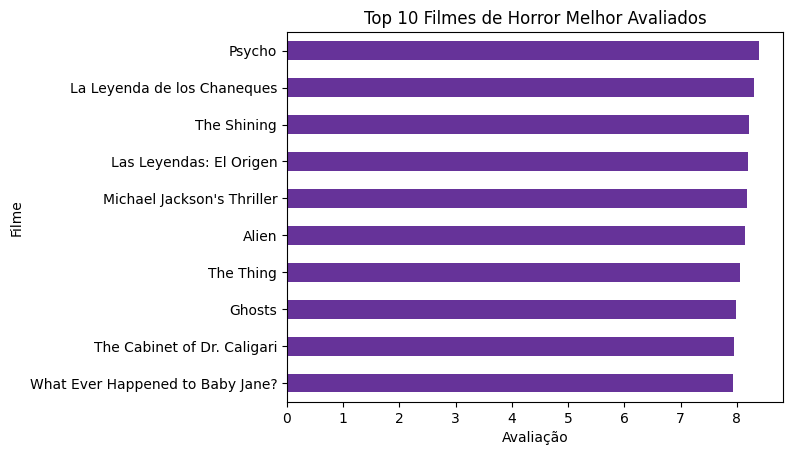

In [106]:
top_10_filmes_avaliacao = df.sort_values(by='Media_Votos', ascending=False).head(10)

ax_f = top_10_filmes_avaliacao.plot(kind="barh", x='Titulo', y='Media_Votos', color="rebeccapurple", legend=False)
plt.ylabel("Filme")
plt.xlabel("Avaliação")
plt.title("Top 10 Filmes de Horror Melhor Avaliados")
plt.xticks(rotation=0)
plt.gca().invert_yaxis()
plt.show()

Quais filmes são mais populares?

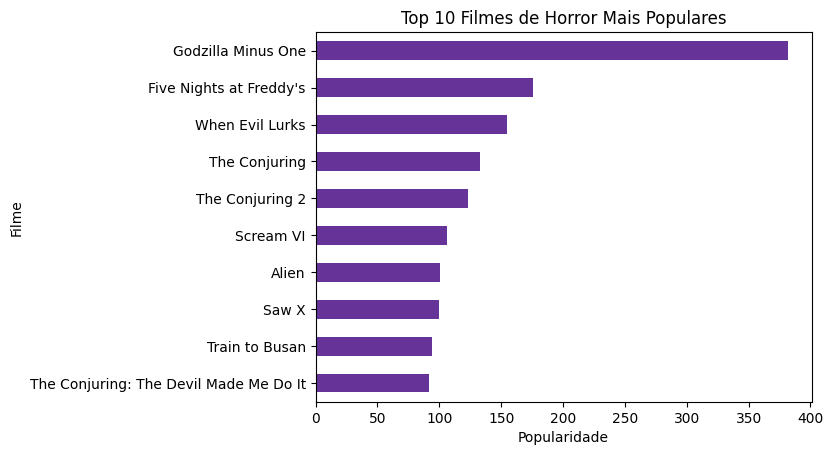

In [105]:
top_10_filmes_popularidade = df.sort_values(by='Popularidade', ascending=False).head(10)

ax_f = top_10_filmes_popularidade.plot(kind="barh", x='Titulo', y='Popularidade', color="rebeccapurple", legend=False)
plt.ylabel("Filme")
plt.xlabel("Popularidade")
plt.title("Top 10 Filmes de Horror Mais Populares")
plt.xticks(rotation=0)
plt.gca().invert_yaxis()
plt.show()

Há uma relação entre a popularidade e a avaliação do filme?

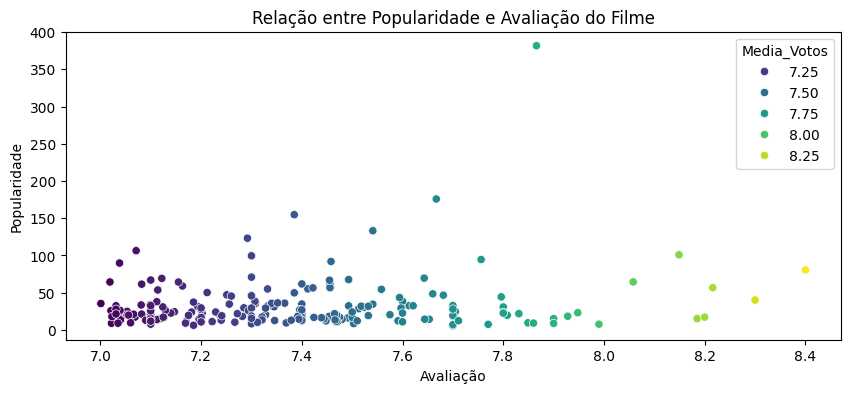

In [87]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df, x='Media_Votos', y='Popularidade', hue='Media_Votos', palette='viridis')
plt.title('Relação entre Popularidade e Avaliação do Filme')
plt.xlabel('Avaliação')
plt.ylabel('Popularidade')
plt.show()

> Não há uma relação direta entre popularidade e melhor avaliação. Como pode-se observar no gráfico acima, há filmes bem avaliados que não são tão populares.

Quais os top 10 diretores que mais fazem filmes de horror?

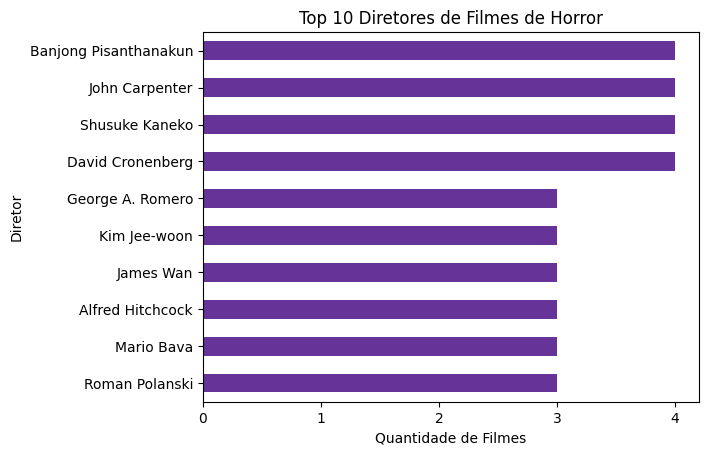

In [108]:
diretores = ['Diretor_1', 'Diretor_2', 'Diretor_3', 'Diretor_4']
serie_diretores = df[diretores].stack()
contagem_diretores = serie_diretores.value_counts()
top_10_diretores = contagem_diretores.head(10)

ax_d = top_10_diretores.plot(kind="barh", color="rebeccapurple")
plt.ylabel("Diretor")
plt.xlabel("Quantidade de Filmes")
plt.title("Top 10 Diretores de Filmes de Horror")
plt.xticks(rotation=0)
plt.gca().invert_yaxis()
# Configura o eixo x para mostrar somente números inteiros
ax_d.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

Quais diretores produzem os filmes mais populares?

Quais os top 10 roteiristas que mais escrevem filmes de horror?

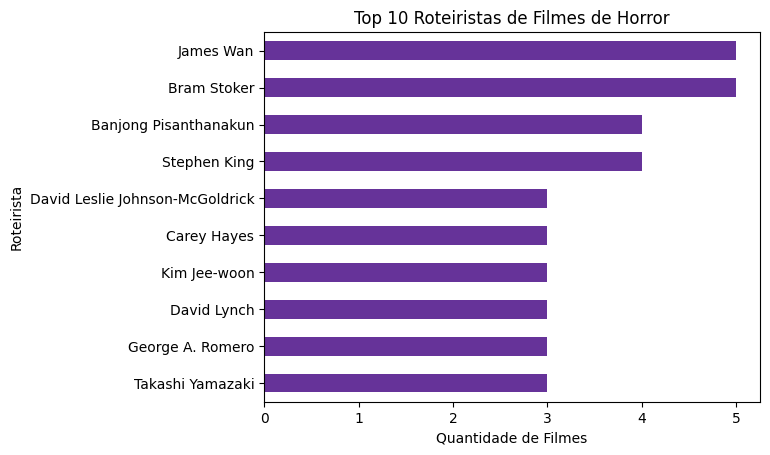

In [92]:
roteiristas = ['Roteirista_1', 'Roteirista_2', 'Roteirista_3', 'Roteirista_4', 'Roteirista_5', 'Roteirista_6', 'Roteirista_7', 'Roteirista_8', 'Roteirista_9', 'Roteirista_10', 'Roteirista_11']
serie_roteiristas = df[roteiristas].stack()
contagem_roteiristas = serie_roteiristas.value_counts()
top_10_roteiristas = contagem_roteiristas.head(10)

ax_r = top_10_roteiristas.plot(kind="barh", color="rebeccapurple")
plt.ylabel("Roteirista")
plt.xlabel("Quantidade de Filmes")
plt.title("Top 10 Roteiristas de Filmes de Horror")
plt.xticks(rotation=0)
plt.gca().invert_yaxis()
ax_r.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

Quais roteiristas produzem os filmes mais bem avaliados?